# Titanic: data exploration and preparation

**Week 0 · Data Science & Agentic AI Programme**

Before building any model we need to **understand** the data and **clean** it. This notebook has two parts:

**Part 1: Explore (find the problems)**
1. First look at the data
2. Missing data
3. Duplicates
4. Outliers

**Part 2: Prepare (fix the problems)**

5. Missing value imputation: mean, median, mode
6. Handling outliers: IQR capping
7. Encoding: turning text into numbers
8. Scaling: putting numbers on the same scale

> **Setup.** In your uv project run `uv add pandas numpy matplotlib scikit-learn jupyter`, then open this notebook in VS Code (or upload it to Google Colab, which already has these installed).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Load the data

If you have `titanic.csv` next to this notebook it is used; otherwise it is downloaded from the internet.

| Column | Meaning |
|---|---|
| `Survived` | 0 = no, 1 = yes |
| `Pclass` | Ticket class: 1 = first, 2 = second, 3 = third |
| `Sex`, `Age` | Passenger's sex and age in years |
| `SibSp` | Number of siblings / spouses on board |
| `Parch` | Number of parents / children on board |
| `Fare` | Ticket price |
| `Cabin` | Cabin number |
| `Embarked` | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

In [2]:
from pathlib import Path

DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
path = "titanic.csv" if Path("titanic.csv").exists() else DATA_URL

df = pd.read_csv(path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# Part 1: Explore

## 1. First look

Four quick questions: **How big is it? What are the columns? What types are they? What do the numbers look like?**

In [3]:
print("Rows, columns:", df.shape)

Rows, columns: (891, 12)


In [4]:
# Column names, data types and how many non-empty values each column has
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Summary statistics for the numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**What to notice**
- There are 891 rows, but `Age` has only 714 values and `Cabin` only 204. **Some data is missing.**
- `Fare` has a mean of about 32 but a maximum of 512. **That looks like an outlier.**

## 2. Missing data

Missing values show up as `NaN` ("not a number"). Most models can't handle them, so we first need to know **where** they are and **how many**.

In [6]:
# How many values are missing in each column?
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# The same as a percentage of all rows, which is easier to judge
missing_pct = (df.isnull().mean() * 100).round(1)
missing_pct[missing_pct > 0].sort_values(ascending=False)

Cabin       77.1
Age         19.9
Embarked     0.2
dtype: float64

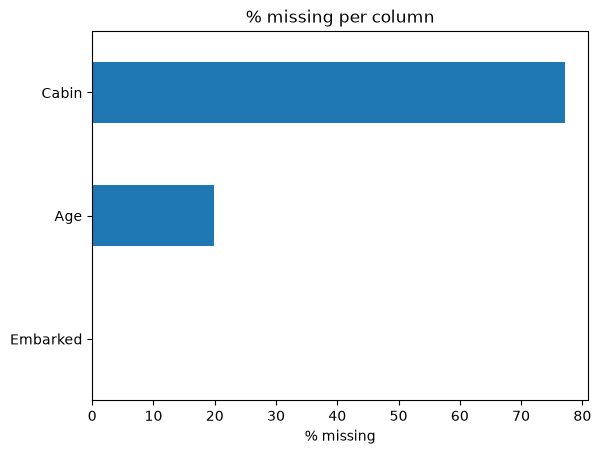

In [8]:
missing_pct[missing_pct > 0].sort_values().plot(kind="barh", title="% missing per column")
plt.xlabel("% missing")
plt.show()

**Three columns have gaps, each a different size:**

| Column | Missing | What we'll do (Part 2) |
|---|---|---|
| `Cabin` | ~77% | Too much missing: **drop the column** |
| `Age` | ~20% | Important column: **fill in** (impute) the gaps |
| `Embarked` | 2 rows | Tiny: fill with the most common value |

## 3. Duplicates

A duplicate is a row that appears more than once. Duplicates make some passengers count twice and can bias a model.

In [9]:
# How many rows are exact copies of an earlier row?
df.duplicated().sum()

np.int64(0)

This dataset is clean: **0 duplicates**. Real data usually isn't, so let's practise by adding 3 copied rows on purpose.

In [10]:
df_with_dupes = pd.concat([df, df.head(3)], ignore_index=True)

print("Rows:", len(df_with_dupes))
print("Duplicates:", df_with_dupes.duplicated().sum())

# Show the duplicated rows (keep=False marks every copy, including the original)
df_with_dupes[df_with_dupes.duplicated(keep=False)]

Rows: 894
Duplicates: 3


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
891,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
892,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
893,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [11]:
# Remove them: keeps the first copy of each row
df_no_dupes = df_with_dupes.drop_duplicates()
print("Rows after drop_duplicates():", len(df_no_dupes))

Rows after drop_duplicates(): 891


## 4. Outliers

An **outlier** is a value far away from the rest. It could be a mistake (age = 400) or genuine but rare (a very expensive ticket).

### See them with a box plot

The box holds the middle 50% of values; the dots beyond the "whiskers" are possible outliers.

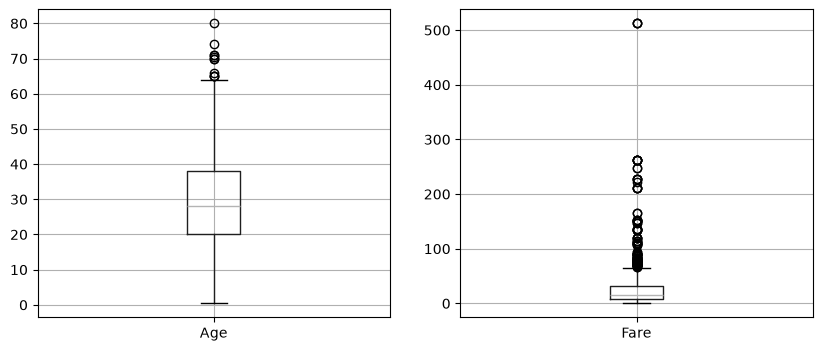

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="Age", ax=axes[0])
df.boxplot(column="Fare", ax=axes[1])
plt.show()

### Find them with the IQR rule

1. **Q1** = 25th percentile, **Q3** = 75th percentile
2. **IQR** = Q3 − Q1 (the spread of the middle half of the data)
3. Anything below **Q1 − 1.5 × IQR** or above **Q3 + 1.5 × IQR** is an outlier

In [13]:
def iqr_bounds(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lower, upper = iqr_bounds(df["Fare"])
print(f"Fare: normal range is {lower:.2f} to {upper:.2f}")

fare_outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]
print("Number of Fare outliers:", len(fare_outliers))
fare_outliers[["Name", "Pclass", "Fare"]].sort_values("Fare", ascending=False).head()

Fare: normal range is -26.72 to 65.63
Number of Fare outliers: 116


,Name,Pclass,Fare
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
258,"Ward, Miss. Anna",1,512.3292
737,"Lesurer, Mr. Gustave J",1,512.3292
341,"Fortune, Miss. Alice Elizabeth",1,263.0000
438,"Fortune, Mr. Mark",1,263.0000


These are mostly **first-class passengers who really paid a lot**, so they are genuine, not mistakes. That's why we usually **cap** outliers rather than delete them (Part 2).

> **Another method: the z-score.** It measures how many standard deviations a value is from the mean; |z| > 3 is often called an outlier. IQR is safer for skewed columns like `Fare`.

---
# Part 2: Prepare

We'll make a copy so the original stays untouched.

In [14]:
clean = df.copy()

## 5. Missing value imputation

**Imputation** means filling in missing values with a sensible estimate.

| Method | Fill with… | Use for | Example |
|---|---|---|---|
| **Mean** | the average | numbers without big outliers | — |
| **Median** | the middle value | numbers **with** outliers or skew | `Age`, `Fare` |
| **Mode** | the most common value | **categories** (text) | `Embarked` |
| **Drop** | remove the column / rows | too much missing, or very few rows | `Cabin` |

### Mean vs median for `Age`

In [15]:
print("Mean age:  ", round(clean["Age"].mean(), 2))
print("Median age:", clean["Age"].median())

Mean age:   29.7
Median age: 28.0


They're close because `Age` isn't very skewed. For `Fare` they're far apart (mean ≈ 32, median ≈ 14) because a few huge fares drag the mean up. **The median isn't pulled by outliers**, so it's the safer default.

In [16]:
# Optional but useful: remember which rows were filled in
clean["Age_was_missing"] = clean["Age"].isnull().astype(int)

# Median imputation
clean["Age"] = clean["Age"].fillna(clean["Age"].median())

# (Mean imputation would be: clean["Age"].fillna(clean["Age"].mean()))
print("Missing Age values now:", clean["Age"].isnull().sum())

Missing Age values now: 0


### Mode for `Embarked` (a category)

In [17]:
most_common_port = clean["Embarked"].mode()[0]
print("Most common port:", most_common_port)

clean["Embarked"] = clean["Embarked"].fillna(most_common_port)
print("Missing Embarked values now:", clean["Embarked"].isnull().sum())

Most common port: S
Missing Embarked values now: 0


### Drop `Cabin` (77% missing)

Filling in 77% of a column would be mostly guesswork, so we drop it.

In [18]:
clean = clean.drop(columns=["Cabin"])
clean.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Age_was_missing    0
dtype: int64

**No missing values left.**

> **Going further:** a smarter fill is the median age **per group**, e.g. per passenger class, since first-class passengers tend to be older:
> `df.groupby("Pclass")["Age"].transform("median")`

## 6. Handling outliers: IQR capping

Instead of deleting outliers, **cap** them: anything above the upper bound is set *to* the upper bound (and the same for the lower bound). This is also called *clipping* or *winsorising*.

Max fare before: 512.33
Max fare after:  65.63


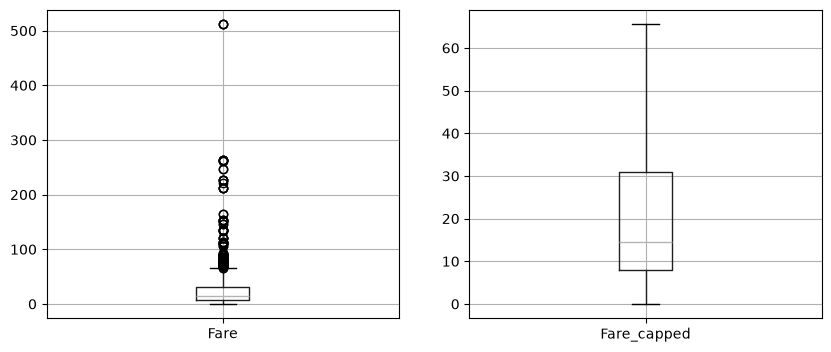

In [19]:
lower, upper = iqr_bounds(clean["Fare"])
clean["Fare_capped"] = clean["Fare"].clip(lower=lower, upper=upper)

print(f"Max fare before: {clean['Fare'].max():.2f}")
print(f"Max fare after:  {clean['Fare_capped'].max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
clean.boxplot(column="Fare", ax=axes[0])
clean.boxplot(column="Fare_capped", ax=axes[1])
plt.show()

| Option | When |
|---|---|
| **Keep** | the outliers are real and important |
| **Cap** (IQR) | real but extreme values that would dominate a model |
| **Remove** | clearly wrong values, e.g. age = 400 |
| **Log transform** `np.log1p(x)` | squashes a long tail like `Fare` |

## 7. Encoding: turning text into numbers

Models only understand numbers, so text columns like `Sex` and `Embarked` must be converted.

### Label encoding: one number per category

Good for **two categories**, or categories with a natural **order** (small < medium < large).

In [20]:
clean["Sex_encoded"] = clean["Sex"].map({"male": 0, "female": 1})
clean[["Sex", "Sex_encoded"]].head()

,Sex,Sex_encoded
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


### One-hot encoding: one 0/1 column per category

Use it when categories have **no order**. If we coded `Embarked` as S=0, C=1, Q=2, the model would wrongly think Q is "bigger" than S. One-hot avoids that.

In [21]:
embarked_dummies = pd.get_dummies(clean["Embarked"], prefix="Embarked", dtype=int)
pd.concat([clean["Embarked"], embarked_dummies], axis=1).head()

,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,S,0,0,1
1,C,1,0,0
2,S,0,0,1
3,S,0,0,1
4,S,0,0,1


In [22]:
clean = pd.concat([clean, embarked_dummies], axis=1)

| Method | Use when | Example |
|---|---|---|
| **Label** | 2 categories, or the categories have an order | `Sex`, size S/M/L |
| **One-hot** | categories with no order | `Embarked` |

`Pclass` is already numeric (1, 2, 3) and has a natural order, so it can stay as it is.

## 8. Scaling: putting numbers on the same scale

`Age` runs from about 0 to 80; `Fare` from 0 to 500. Many models (KNN, SVM, linear models, neural networks) would treat `Fare` as more important **just because its numbers are bigger**. Scaling fixes that.

| Method | Formula | Result |
|---|---|---|
| **Min-Max scaling** | (x − min) / (max − min) | values between **0 and 1** |
| **Standardisation** (z-score) | (x − mean) / std | mean **0**, standard deviation **1** |

In [23]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

cols = ["Age", "Fare_capped"]

minmax = MinMaxScaler().fit_transform(clean[cols])
standard = StandardScaler().fit_transform(clean[cols])

comparison = pd.DataFrame({
    "Age": clean["Age"],
    "Age_minmax": minmax[:, 0],
    "Age_standard": standard[:, 0],
    "Fare": clean["Fare_capped"],
    "Fare_minmax": minmax[:, 1],
    "Fare_standard": standard[:, 1],
}).round(2)
comparison.head()

,Age,Age_minmax,Age_standard,Fare,Fare_minmax,Fare_standard
0,22.0,0.27,-0.57,7.25,0.11,-0.82
1,38.0,0.47,0.66,65.63,1.00,2.03
2,26.0,0.32,-0.26,7.92,0.12,-0.79
3,35.0,0.43,0.43,53.10,0.81,1.42
4,35.0,0.43,0.43,8.05,0.12,-0.78


In [24]:
comparison.describe().loc[["min", "max", "mean", "std"]].round(2)

,Age,Age_minmax,Age_standard,Fare,Fare_minmax,Fare_standard
min,0.42,0.00,-2.22,0.00,0.00,-1.17
max,80.00,1.00,3.89,65.63,1.00,2.03
mean,29.36,0.36,0.00,24.05,0.37,-0.00
std,13.02,0.16,1.00,20.48,0.31,1.00


After scaling, `Age` and `Fare` are on comparable scales: Min-Max puts both between 0 and 1; standardisation centres both at 0 with a standard deviation of 1.

**Which one?**
- **Standardisation** is the usual default, especially for linear models, SVMs and neural networks.
- **Min-Max** when you need a fixed 0–1 range (e.g. images, some neural networks).
- **Tree models** (decision trees, random forests, XGBoost) **don't need scaling**.

> ⚠️ **Data leakage.** In a real project, split into train and test sets **first**, then `fit` the scaler (and compute medians, modes and IQR bounds) on the **training** data only. We'll cover this properly in Week 1.

---
## Final cleaned dataset

In [25]:
model_ready = clean[[
    "Survived", "Pclass", "Sex_encoded", "Age", "Age_was_missing", "SibSp", "Parch",
    "Fare_capped", "Embarked_C", "Embarked_Q", "Embarked_S",
]]
print("Shape:", model_ready.shape)
print("Missing values:", model_ready.isnull().sum().sum())
model_ready.head()

Shape: (891, 11)
Missing values: 0


,Survived,Pclass,Sex_encoded,Age,Age_was_missing,SibSp,Parch,Fare_capped,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,0,1,0,7.2500,0,0,1
1,1,1,1,38.0,0,1,0,65.6344,1,0,0
2,1,3,1,26.0,0,0,0,7.9250,0,0,1
3,1,1,1,35.0,0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,0,8.0500,0,0,1


## Cheat sheet

| Problem | Find it | Fix it |
|---|---|---|
| Missing values | `df.isnull().sum()` | `fillna(median)` for numbers, `fillna(mode)` for categories, or `drop(columns=…)` |
| Duplicates | `df.duplicated().sum()` | `df.drop_duplicates()` |
| Outliers | box plot, IQR rule | `clip(lower, upper)` to cap, or a log transform |
| Text categories | `df.dtypes` | `map()` for label encoding, `pd.get_dummies()` for one-hot |
| Different scales | `df.describe()` | `StandardScaler`, `MinMaxScaler` |

## Try it yourself

1. Fill `Age` with the **mean** instead of the median. How much does the average age change?
2. How many `Age` outliers does the IQR rule find?
3. One-hot encode `Pclass`. When would that be better than leaving it as 1/2/3?
4. Fill `Age` with the median **per `Pclass`** (see the "Going further" tip in section 5).